# Basic data access

Wikipedia, and virtually all other Wiki projects that are run under the umbrella of the [Wikimedia Foundation](https://wikimediafoundation.org/), are using an open-source software called *[MediaWiki](https://www.mediawiki.org/)*. It is also used outside the Wikimedia universe, in a wide range of settings. For example, researchers are aggregating information about biochemical pathways in the [WikiPathways](https://www.wikipathways.org/) project, German-speaking patients with cluster headaches use it for [creating their own knowledge base](https://ck-wissen.de/ckwiki/index.php?title=Hauptseite), and in the [*Personal Science Wiki*](https://wiki.openhumans.org/wiki/Personal_Science_Wiki) people are sharing their n-of-1 citizen science efforts.  

Here, we will mainly exploring using the default MediaWiki REST APIs as provided through the *PyWikiBot* Python library. 
But you can also read the [Wikimedia Research overview for how to access data](https://meta.wikimedia.org/wiki/Research:Data).  

## APIs

To facilitate the programmatic and automatic access to the pages that people create, MediaWiki (and the Wikimedia Foundation) offer different APIs that can be used to access data and edit objects in Wikipedia and its many sister projects.

Namely, there are three different API classes with different focuses on use cases, two of which based are on the [REST](https://en.wikipedia.org/wiki/REST) style:

1. **[Wikimedia REST API](https://www.mediawiki.org/wiki/Wikimedia_REST_API)** (pro: fast/simple access, con: limited to very narrow types of data necessary for content)
2. **[MediaWiki REST API](https://www.mediawiki.org/wiki/API:REST_API)** (pro: also simple/fast access, con: limited to certain types of data)
3. **[MediaWiki Action API](https://www.mediawiki.org/wiki/API:Action_API)** (pro: very powerful, gives access to virtually all types of data, con: harder to use, rate-limited when used remotely)

### Wikimedia REST API

This custom API – that is particular to the Wikimedia projects – is designed for delivering high-throughput access to the content and metadata of Wikimedia projects in different, machine-readable formats. As a result, it offers a very narrow and highly optimized access to 'live' pages and content.

This focus makes it less relevant for research, where we might want to understand longitudinal changes in how articles have evolved.

### MediaWiki REST API

The standard REST API of MediaWiki is present in all MediaWiki installations and can be used to get data in JSON or HTML from them. Similar to the *Wikimedia*-specific API, this is mostly useful for accessing current data through simple API endpoints that return fast responses.

For those reasons, depending on the research question, it might be of limited utility.

### MediaWiki Action API

The Action API is the most powerful API that MediaWiki offers. Beyond accessing a wide range of data, it can even be used to submit and edit data. For this reason, it is also at the heart of the large *service bot* ecosystem of Wikipedia and its related projects. Run by Wikipedia contributors, these bots help detect wrongly formatted citations, replace broken links with still accessible archived versions, or fix common language issues.

It also offers the most possibilities to access data from Wikipedia for research purposes, as it provides the detailed edit histories of pages, allows detailed searches across pages and users, and also provides access to public user details, like a user's editing history, gender (if provided) and other details.

We will focus on the Action API in the following materials.

## Using the Action API with *PyWikiBot*

The *Action API* can be used through any programming language by sending correctly formatted HTTP requests to it, but as the API is very feature-rich, this quickly becomes quite complex.

Luckily, the Wikimedia Foundation maintains a Python library called *[Pywikibot](https://doc.wikimedia.org/pywikibot/stable/index.html)* that can be used interact with the various endpoints the API offers and also wraps the responses into objects that are easier to work with. Importantly, it **also ensures that we honor the rate limits** of the API, to ensure we don't overwhelm the server endpoints.

You can use this library either locally on your computer, or [use it in the **PAWS** JupyterLab environment](https://wikitech.wikimedia.org/wiki/PAWS) that the Wikimedia Foundation offers.

### Local setup

If you want to use the library locally, it can be installed through `pip` from the commandline: 

```
pip install pywikibot
```

After the installation, we also need to create a user config, in which we need to add our username that we use to identify us as the user of the API. To create the file you can run the following from your terminal:

```
pwb generate_user_files
```

It creates a small `user-config.py` file in which we add the configuration details. This file should be **located in the same folder from which you will run your Python scripts**. 

You can now start a Jupyter notebook and start interacting with the API.

First, to confirm that the config is found in the notebook, we run the following:

In [1]:
!cat user-config.py

family = 'wikipedia'
mylang = 'en'
usernames['wikipedia']['en'] = 'Gedankenstuecke'
usernames['wikipedia']['de'] = 'Gedankenstuecke'
usernames['wikipedia']['es'] = 'Gedankenstuecke'
usernames['wikipedia']['fr'] = 'Gedankenstuecke'
usernames['wikipedia']['it'] = 'Gedankenstuecke'
usernames['wikidata']['wikidata'] = 'Gedankenstuecke'
password_file = None


We see the username details, here for the English language-version of Wikipedia, as well as some further language versions and Wikidata.

### Using *PAWS*

[PAWS](https://wikitech.wikimedia.org/wiki/PAWS) is the *Jupyter Notebook/Lab* environment that is hosted on the servers of the Wikimedia Foundation (WMF). 
That means, you don't have to install anything locally on your computers, and all of the actual computations are happening on the servers of the WMF.
Instead, you can access the compute environment via your web browser.

The virtual compute resources that PAWS provides to each user include 1 CPU, 2G of RAM and 5G of storage.
This should be enough for many research projects, especially to get started.

**One important thing to keep in mind: All notebooks you write on *PAWS* [are publicly accessible](https://wikitech.wikimedia.org/wiki/PAWS/About_Jupyter_notebooks_hosted_on_PAWS#Use_responsibly), so don't share passwords or other private information in it!**

#### Accessing *PAWS*

To access *PAWS* you will need a *single user wikimedia* account.
These accounts are shared between all Wikimedia projects (like the different Wikipedia language editions and Wikidata), including *PAWS*.
If you don't have an account yet, you can [create one here](https://auth.wikimedia.org/mediawikiwiki/wiki/Special:CreateAccount). 

Once you have an account you [can login and launch your Jupyter environment](https://wikitech.wikimedia.org/wiki/PAWS).

Using *PAWS* has the additional benefit that it comes with *PyWikiBot* preconfigured to use your *unified user account*, so you don't have to do any heavy lifting for setting it up. 

For this reason, **we will be using *PAWS* for the rest of this course, ensuring that your development environment for accessing Wikipedia is pre-configured**.

## Getting started using *PyWikiBot* 

Now we can actually go ahead with loading the libary, confirming once more that the username was correctly set, and do our first query of Wikipedia through the library.

For that, we create a `site` object, that tells `pywikibot` which Wikimedia project we want to interact with, by giving the same 2-letter acronym of the language, and the project itself.

We can then use the site object to query through the *pywikibot*, for example for the page on computational social sciences:

In [2]:
import pywikibot

print("Config: {}\n".format(
    pywikibot.config.usernames)
     )

site = pywikibot.Site('en', 'wikipedia') # select the wikimedia project we want to interact with
page = pywikibot.Page(site, "Computational social science") # give name of page we want to use

print("Title: {}\n".format(
    page.title()
    ))
print("Start of article:\n\n{}…\n".format(
    page.text[:1000]
    ))

Config: defaultdict(<class 'dict'>, {'wikipedia': {'en': 'Gedankenstuecke', 'de': 'Gedankenstuecke', 'es': 'Gedankenstuecke', 'fr': 'Gedankenstuecke', 'it': 'Gedankenstuecke'}, 'wikidata': {'wikidata': 'Gedankenstuecke'}})

Title: Computational social science

Start of article:

{{Short description|Academic sub-disciplines}}
{{broader|Quantitative social research}}

'''Computational social science''' is an interdisciplinary academic sub-field concerned with computational approaches to the [[social science]]s.
This means that computers are used to model, simulate, and analyze social phenomena. 
It has been applied in areas such as [[computational economics]], [[computational sociology]], computational media analysis, [[cliodynamics]], [[culturomics]], [[nonprofit studies]].<ref>{{Cite journal |last1=Ma |first1=Ji |last2=Ebeid |first2=Islam Akef |last3=de Wit |first3=Arjen |last4=Xu |first4=Meiying |last5=Yang |first5=Yongzheng |last6=Bekkers |first6=René |last7=Wiepking |first7=Pamala |

## Exploring a page object

We now got the page on *Computational social science* in the `page` object and can access information from it, e.g. using a function like `page.title()` or accessing data like `page.text` above.

To see the full list of methods and values associated with it, we can see all of them like this below (we use the filtering approach, as `dir(page)` in itself would show all methods, including private ones that aren't supposed to be used directly).

In [112]:
[i for i in dir(page) if not i.startswith("_")]

['WIKIBLAME_CODES',
 'WIKIWHO_CODES',
 'applicable_protections',
 'authorship',
 'autoFormat',
 'backlinks',
 'botMayEdit',
 'categories',
 'change_category',
 'clear_cache',
 'content_model',
 'contributors',
 'coordinates',
 'create_short_link',
 'data_item',
 'data_repository',
 'defaultsort',
 'delete',
 'depth',
 'embeddedin',
 'exists',
 'expand_text',
 'extlinks',
 'extract',
 'full_url',
 'get',
 'getCategoryRedirectTarget',
 'getDeletedRevision',
 'getOldVersion',
 'getRedirectTarget',
 'getReferences',
 'getVersionHistoryTable',
 'get_annotations',
 'get_best_claim',
 'get_parsed_page',
 'get_revision',
 'has_content',
 'has_deleted_revisions',
 'has_permission',
 'image_repository',
 'imagelinks',
 'interwiki',
 'isAutoTitle',
 'isCategoryRedirect',
 'isDisambig',
 'isIpEdit',
 'isRedirectPage',
 'isStaticRedirect',
 'isTalkPage',
 'is_categorypage',
 'is_filepage',
 'is_flow_page',
 'iterlanglinks',
 'itertemplates',
 'langlinks',
 'lastNonBotUser',
 'latest_revision',
 'la

There is a couple of interesting methods we will look at more closely: `authorship`, `contributors`, `revisions`, and `categories`. 

### Authorship

To check how authorship for the current, i.e. latest version of the page distributes across different contributors, we can use the `authorship` method. Each tupel of the form `(1234, 50.0)` gives the authorship in character count (`1234`) and percentage of the article `(50.0`):

In [114]:
page.authorship()

{'MattiNelimarkka': (3616, 23.0),
 'Hoyerdan': (3144, 20.0),
 '~2025-34400-27': (1257, 8.0),
 '46.233.116.47': (1100, 7.0),
 '2605:E000:1521:DB:B1CE:3E73:4742:6DD8': (786, 5.0)}

We can see that both registered accounts (`MattiMelimarkka`) as well as anonymous contributors have made edits. In the past, anonymous contributions were saved under the IP address from which edits were made (e.g. `2605:E000:1521:DB:B1CE:3E73:4742:6DD8` or `46.233.116.47`), while today temporary user names are assigned (e.g. `~2025-34400-27`).

### Contributors

Instead of just looking at the latest version, we can also get the list of all people who ever contributed and their number of edits, using the `contributors` method. This will give us a tuple containing the username and the number of edits:

In [138]:
list(page.contributors())

['SchlurcherBot',
 'Monkbot',
 'OAbot',
 '~2025-34400-27',
 'Folkezoft',
 'David Delony',
 'Allforrous',
 'Sythoz',
 'LucasBrown',
 'Citation bot',
 'Me, Myself, and I are Here',
 'Dicklyon',
 'MattiNelimarkka',
 'JCW-CleanerBot',
 '106.185.147.172',
 'WikiCleanerBot',
 'ContinueWithCaution',
 'Konila21',
 'Ira Leviton',
 '72.182.36.82',
 'Leosonh',
 'Jarble',
 'Liz',
 'MrOllie',
 'Xxpaulm',
 'Fgnievinski',
 'WheezePuppet',
 'InternetArchiveBot',
 '129.170.195.199',
 'Izno',
 '103.106.200.56',
 '2A01:C50E:2121:0:449F:4A20:B919:4EC2',
 'BHGbot',
 'Kvng',
 'Marnie Hawes',
 '45.243.222.143',
 'Fadesga',
 'IznoRepeat',
 'Christianssand',
 '217.16.13.130',
 'Smasongarrison',
 'GünniX',
 'Jeffwinchell',
 '193.227.11.122',
 'Deeahbz',
 'KolbertBot',
 'Askedonty',
 '197.48.29.120',
 'Fixuture',
 'Rjwilmsi',
 'Melcous',
 'Bigdata',
 '67.212.234.180',
 'HelpUsStopSpam',
 'Vonbergh',
 'Gilliam',
 '193.227.11.124',
 'Jauerback',
 'Alannanoellelaz',
 'BG19bot',
 '94.174.197.67',
 '46.233.116.47',
 

With this, we now also see some of the service bots that identify as such in their name already, like the `WikiCleanerBot` or the `InternetArchiveBot`.

### Page revisions

If we want to understand the actual editing history of the page, we can get a list of all revisions, which allows us to see how the page evolved over time.

*Note: We'll just look at the 10 most recent edits to keep the notebook a bit cleaner, but in principle you can see all edits by not using `break`*

In [124]:
print("This page has {} revisions".format(page.revision_count()))

rev = 0
for revision in page.revisions():
    print("{} edited the article on {} with this edit comment:\n\t{}\n---".format(
        revision['user'],
        revision['timestamp'],
        revision['comment']))
    rev += 1
    if rev > 10:
        break

This page has 135 revisions
SchlurcherBot edited the article on 2026-02-12T21:46:58Z with this edit comment:
	Bot: http → https
---
Monkbot edited the article on 2025-11-27T20:44:07Z with this edit comment:
	/* Definitions */ [[User:Monkbot/task 21: Replace page(s) with article-number|Monkbot/task 21: Replace page(s) with article-number]];
---
OAbot edited the article on 2025-11-24T07:09:33Z with this edit comment:
	[[Wikipedia:OABOT|Open access bot]]: pmc updated in citation with #oabot.
---
~2025-34400-27 edited the article on 2025-11-18T00:06:45Z with this edit comment:
	Added Gilardi and Bermejo as benchmarks against humans
---
Monkbot edited the article on 2025-09-30T07:15:29Z with this edit comment:
	/* Definitions */ [[User:Monkbot/task 21: Replace page(s) with article-number|Monkbot/task 21: Replace page(s) with article-number]];
---
Folkezoft edited the article on 2025-08-13T03:00:35Z with this edit comment:
	/* Definitions */ Tag [[Wikipedia:Bare URLs|Bare URLs]] using [[Wiki

By default, the revisions that are returned do not include the text of the previous revisions, but if we pass `content=True` in the method call, those will be returned too:

In [130]:
for revision in page.revisions(content=True):
    print(revision.text[:500])
    break

{{Short description|Academic sub-disciplines}}
{{broader|Quantitative social research}}

'''Computational social science''' is an interdisciplinary academic sub-field concerned with computational approaches to the [[social science]]s.
This means that computers are used to model, simulate, and analyze social phenomena. 
It has been applied in areas such as [[computational economics]], [[computational sociology]], computational media analysis, [[cliodynamics]], [[culturomics]], [[nonprofit studies


### Categories

In Wikipedia, virtually all articles are in one to many different categories. We can explore which category a page belongs to through the `page.categories` method:

In [133]:
for cat in page.categories():
    print(cat)

[[en:Category:All Wikipedia articles in need of updating]]
[[en:Category:All articles with bare URLs for citations]]
[[en:Category:Articles with bare URLs for citations from August 2025]]
[[en:Category:Articles with short description]]
[[en:Category:Commons category link is defined as the pagename]]
[[en:Category:Computational social science]]
[[en:Category:Short description is different from Wikidata]]
[[en:Category:Webarchive template wayback links]]
[[en:Category:Wikipedia articles in need of updating from March 2024]]


## Exploring a user object

Above, we have seen how we can access pages in Wikipedia and also get some details about how edited that given page. The API also offers method to dig a bit into who those contributors are and what edits they made.

To access details about a single user, we can use `pywikibot.User` and then look at the methods that are accessible. Here, we are using Bastian's user name to be able to get some 'real' data for demonstration purposes, but of course you can replace `Gedankenstuecke` with any user name. 

In [153]:
user = pywikibot.User(site, "Gedankenstuecke") 

[i for i in dir(user) if not i.startswith("_")]

['WIKIBLAME_CODES',
 'WIKIWHO_CODES',
 'applicable_protections',
 'authorship',
 'autoFormat',
 'backlinks',
 'block',
 'botMayEdit',
 'categories',
 'change_category',
 'clear_cache',
 'content_model',
 'contributions',
 'contributors',
 'coordinates',
 'create_short_link',
 'data_item',
 'data_repository',
 'defaultsort',
 'delete',
 'deleted_contributions',
 'depth',
 'editCount',
 'embeddedin',
 'exists',
 'expand_text',
 'extlinks',
 'extract',
 'first_edit',
 'full_url',
 'gender',
 'get',
 'getCategoryRedirectTarget',
 'getDeletedRevision',
 'getOldVersion',
 'getRedirectTarget',
 'getReferences',
 'getUserPage',
 'getUserTalkPage',
 'getVersionHistoryTable',
 'get_annotations',
 'get_best_claim',
 'get_block_info',
 'get_parsed_page',
 'get_revision',
 'getprops',
 'groups',
 'has_content',
 'has_deleted_revisions',
 'has_permission',
 'image_repository',
 'imagelinks',
 'interwiki',
 'isAnonymous',
 'isAutoTitle',
 'isCategoryRedirect',
 'isDisambig',
 'isEmailable',
 'isIpEdi

Some interesting bits for users are the `editCount`, if they gave their gender, if they are currently blocked from editing, and also what contributions they made. Let's explore those:

In [164]:
print("user gave gender as {}".format(
    user.gender()
    ))

print("user is blocked? {}".format(
    user.is_blocked()
    ))

print("user made {} edits\n".format(
    user.editCount()
    ))

print("user contributions:")
c = 0
for contrib in user.contributions():
    print(contrib)
    c += 1
    if c > 10:
        break

user gave gender as unknown
user is blocked? False
user made 149 edits

user contributions:
(Page('Sierras de Córdoba'), 1352554752, Timestamp(2026, 5, 4, 22, 8, 44), 'fix name of cerro mogote')
(Page('Sierras de Córdoba'), 1352554625, Timestamp(2026, 5, 4, 22, 7, 29), 'add details about los gigantes as natural reserve and tourism spot')
(Page('Los Gigantes'), 1352553589, Timestamp(2026, 5, 4, 21, 57, 18), 'add disambiguation option')
(Page('Draft:Stuart Vines'), 1351709685, Timestamp(2026, 4, 29, 17, 26, 26), 'fix name spelling in infobox')
(Page('Draft:Stuart Vines'), 1351703667, Timestamp(2026, 4, 29, 16, 36, 38), 'Submitting using [[WP:AFCSW|AfC-submit-wizard]]')
(Page('Draft talk:Stuart Vines'), 1351703585, Timestamp(2026, 4, 29, 16, 35, 39), 'Adding WikiProject tags ([[MediaWiki:AFC-add-project-tags.js|assisted]])')
(Page('Draft:Stuart Vines'), 1351703472, Timestamp(2026, 4, 29, 16, 34, 49), '-- Draft creation using the [[WP:Article wizard]] --')
(Page('Tupungato'), 1351597508, T

## Accessing categories

We have already seen that pages can be in different categories. Categories are a particular type of *page* that is used to group pages that belong together. 

We can also use categories as a starting point to get a collection of related pages. To do that, we use the `pywikibot.Category` method, using the *Kenyan politicians* category as a starting point:

In [166]:
site = pywikibot.Site('en', 'wikipedia') # select the wikimedia project we want to interact with
politician_pages = [] # to store page names and handles after iterating over category
category = pywikibot.Category(site, "Kenyan politicians") # select category

for i in category.articles():
    politician_pages.append(i)

print("There are {} pages in the 'Kenyan politicians' category".format(len(politician_pages)))

There are 102 pages in the 'Kenyan politicians' category


By iterating over the category, we find 102 pages that are part of it. 

While this is a good starting point, in reality the English language edition of Wikipedia has more pages about Kenyan politicians and who aren't listed in this category, due to how sub-categories in Wikipedia work.

If we go to the Category on Wikipedia, we see 12 sub-categories for e.g. *Kenyan politicians by party*, *stubs* (new/short articles) and more.

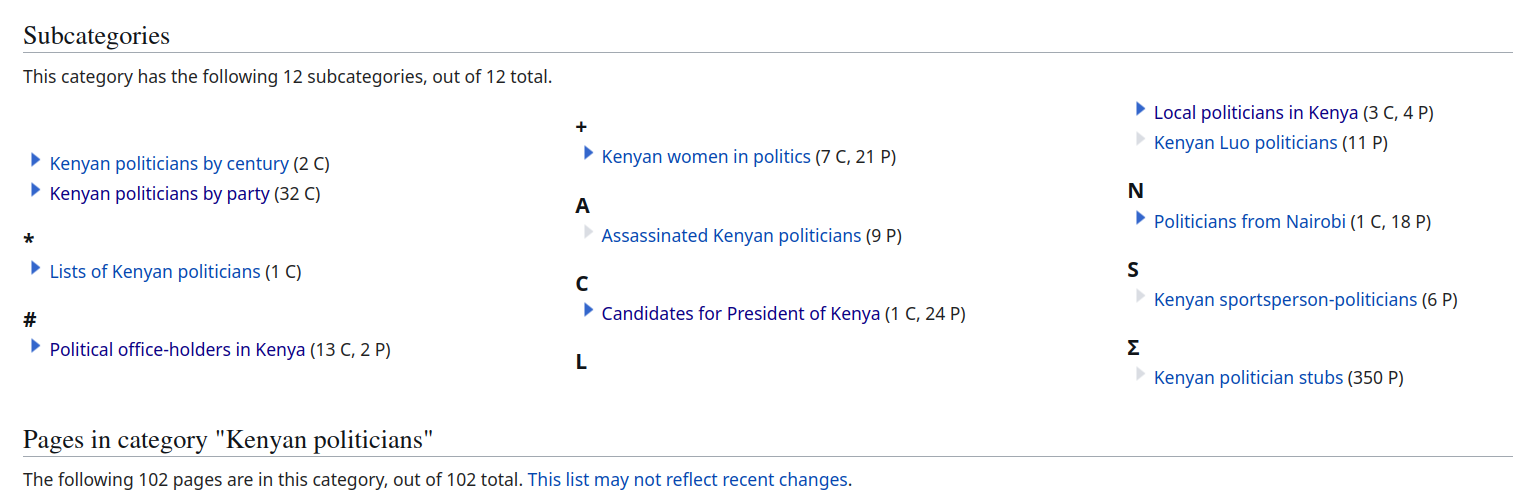

Pages in these sub-categories won't be listed as part of the higher-level category by default. But we can recurse through those lists to ensure that we also get those pages in the subcategories:

In [167]:
for i in category.articles(recurse=True):
    politician_pages.append(i)

print("There are {} pages in the 'Kenyan politicians' category".format(len(politician_pages)))

There are 1039 pages in the 'Kenyan politicians' category


This now gives us a substantially larger number of pages about Kenyan politicians to work with.

## Aggregating and Exploring the data

Now that we have seen the different ways that we can access this data, let's start to aggregate and visually explore this data a bit.

Maybe we would ultimately like to have a large `DataFrame` or table, that contains the full edit history for all the pages in our category of interest, to explore how pages changed over time..

### Using a single page as an example

To get started, we will go through the process by using a single page of the category for demonstration purposes - and then plot the contributions per user to this article – as measured by the number of submitted revisions and the total of added/removed characters as well.

We then:

1. get all the revisions into a dataframe
2. add the page title (which we will need for merging all pages into one table later on), and 
3. calculate the size difference of the article, to evaluate how much text each edit added/removed

In [172]:
import pandas as pd # load pandas to get Dataframes and all related methods

p = politician_pages[2] # pick an article

# get all revisions for the article, including the actual article
df = pd.DataFrame(p.revisions(content=True)) 

# add title, which is missing from revisions, as new column `page_title`
df['page_title'] = p.title() 

# calculate size difference between revisions using current/previous revision

df['size_difference'] = df['size'] - df['size'].shift(periods=-1, fill_value=0) 


df.head(5)

,revid,parentid,user,temp,userid,timestamp,size,sha1,roles,slots,...,parsedcomment,tags,anon,minor,userhidden,commenthidden,text,contentmodel,page_title,size_difference
0,1353017535,1352955026,~2026-27873-85,,53666482,2026-05-07 17:27:58,11702,54f895c341ba5e02ffaee873e5003946a7571ada,[main],"{'main': {'contentmodel': 'wikitext', 'content...",...,"<span class=""autocomment""><a href=""/wiki/Rosly...","[mobile edit, mobile web edit]",False,False,False,False,{{Short description|Kenyan politician (born 19...,wikitext,Roslyne Akombe,-8
1,1352955026,1345291761,~2026-27566-80,,53657954,2026-05-07 06:56:46,11710,e6578bd9c7ae21879052ce70ed519d8c047ced07,[main],"{'main': {'contentmodel': 'wikitext', 'content...",...,,[wikieditor],False,False,False,False,{{Short description|Kenyan politician (born 19...,wikitext,Roslyne Akombe,16
2,1345291761,1342238182,LionmerterTHE,NaN,49865477,2026-03-25 10:34:29,11694,98f8589ccba62702aa5d4b4611a4a8c3b0caea6a,[main],"{'main': {'contentmodel': 'wikitext', 'content...",...,"<span class=""autocomment""><a href=""/wiki/Rosly...",[AWB],False,True,False,False,{{Short description|Kenyan politician (born 19...,wikitext,Roslyne Akombe,-1
3,1342238182,1327823244,Ser Amantio di Nicolao,NaN,753665,2026-03-07 21:29:55,11695,8631fa0b036c31c21567e51cac3cb44a82b3ecb6,[main],"{'main': {'contentmodel': 'wikitext', 'content...",...,"<span class=""autocomment""><a href=""/wiki/Rosly...",[AWB],False,False,False,False,{{Short description|Kenyan politician (born 19...,wikitext,Roslyne Akombe,-25
4,1327823244,1327823189,Eleosyne,NaN,49749298,2025-12-16 08:04:46,11720,b1c7e676b7268b23f046cd7e7b78f14109d50156,[main],"{'main': {'contentmodel': 'wikitext', 'content...",...,Added a category,[visualeditor],False,False,False,False,{{Short description|Kenyan politician (born 19...,wikitext,Roslyne Akombe,30


#### Plotting the number of edits per editor

For this chosen page, let's now visualize the number of edits made by the different editors as measured by saved revisions:

<Axes: xlabel='user'>

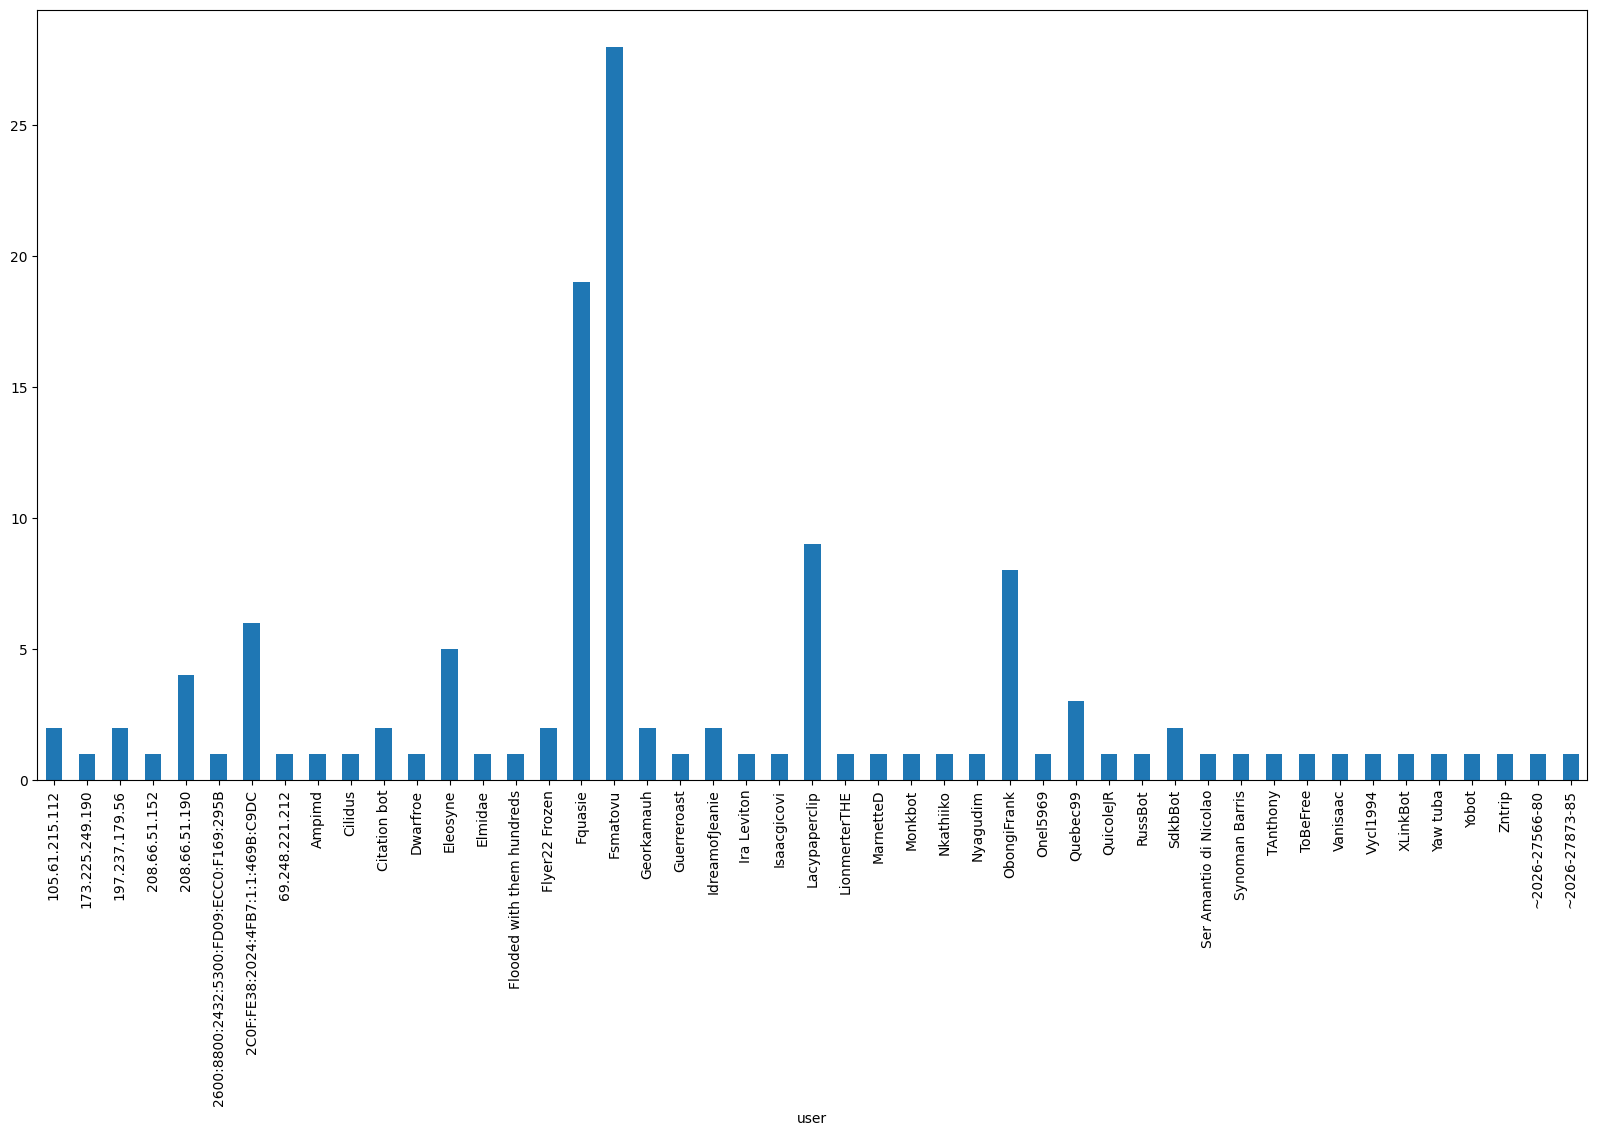

In [175]:
df.groupby(["user"]).count()['userid'].plot(kind='bar', figsize=(20,10))

#### Plotting the overall size change made by the editor

Of course, the number of revisions does not tell us everything. Some editors might make big edits in a single change, while others might break their edits in many small changes. And some might mostly add new information, while others delete outdated/wrong details. So let's look at the 'article size changes' per editor:

*Note: A user could show up as "zero" edits, if they added and removed text of the same volume*

<Axes: xlabel='user'>

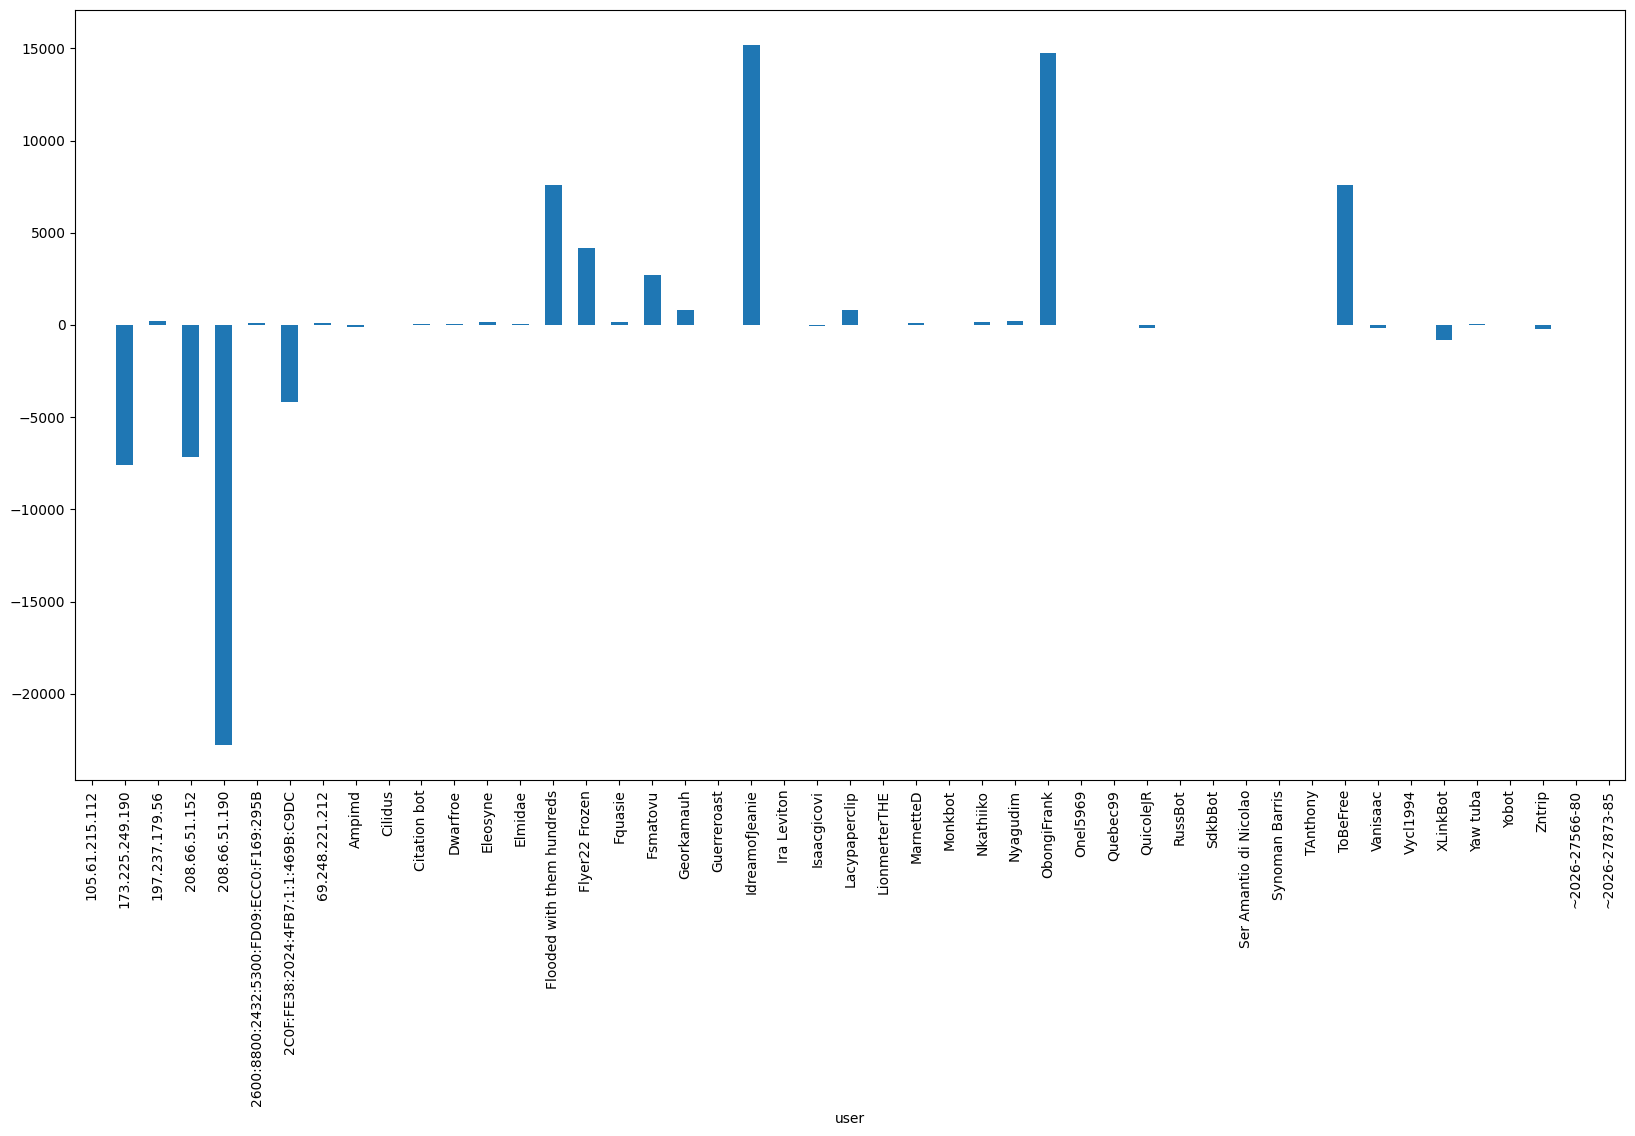

In [178]:
df.groupby('user')['size_difference'].sum().plot(kind='bar', figsize=(20,10))

### Creating a `DataFrame` for all pages

Now that we better understand the type of data we will get, and got a working code to create a `DataFrame` over all revisions of a single page, let's zoom one more step out - and create it for all pages in our category.

**Warning:** Actually executing this code will likely take a while given the API rate limits that MediaWiki enforces and that *Pywikibot* will respect.

In [4]:
# create empty dataframe to hold all data eventually
df_politicians = pd.DataFrame()

for p in politician_pages:
    # create dataframe that holds the revisions for a given page
    # also add the title & size diff as above
    df = pd.DataFrame(p.revisions(content=True))
    df['page_title'] = p.title() 
    df['size_difference'] = df['size'] - df['size'].shift(periods=-1, fill_value=0)
    # if this is not first iteration, concatenate existing data & new page
    if not df_politicians.empty:
        df_politicians = pd.concat([df_politicians, df])
    # otherwise just create aggregate DF 
    else:
        df_politicians = df

# Let's save our data in a CSV file, especially given how long it can take to run this
df_politicians.to_csv('pages_category_kenyian_politicians.csv')

df_politicians.head()

,revid,parentid,minor,user,userid,timestamp,size,sha1,roles,slots,...,anon,userhidden,commenthidden,text,contentmodel,page_title,size_difference,temp,sha1hidden,suppressed
0,1285549690,1284245409,True,Almaddy2022,44620763.0,2025-04-14 10:08:57,4224,dac6097a46b4f8553538a7cd72f8e21144a98f25,[main],"{'main': {'contentmodel': 'wikitext', 'content...",...,False,False,False,{{short description|Kenyan writer and politica...,wikitext,Abdilatif Abdalla,8,NaN,NaN,NaN
1,1284245409,1241910337,False,Almaddy2022,44620763.0,2025-04-06 12:24:59,4216,9702f3020b6af39bfe3d4c665ddff5caa65b9b51,[main],"{'main': {'contentmodel': 'wikitext', 'content...",...,False,False,False,{{short description|Kenyan writer and politica...,wikitext,Abdilatif Abdalla,93,NaN,NaN,NaN
2,1241910337,1215802812,True,Inter&anthro,18180119.0,2024-08-23 20:59:25,4123,3855f560b43074cb4ddf410042636935866d6e54,[main],"{'main': {'contentmodel': 'wikitext', 'content...",...,False,False,False,{{short description|Kenyan writer and politica...,wikitext,Abdilatif Abdalla,38,NaN,NaN,NaN
3,1215802812,1215802775,False,IOHANNVSVERVS,24759391.0,2024-03-27 06:08:59,4085,edde49d1d4e95abcdd491f4e142fdd2f3fed23eb,[main],"{'main': {'contentmodel': 'wikitext', 'content...",...,False,False,False,{{short description|Kenyan writer and politica...,wikitext,Abdilatif Abdalla,-1,NaN,NaN,NaN
4,1215802775,1215802684,False,IOHANNVSVERVS,24759391.0,2024-03-27 06:08:39,4086,6e4050681632db2525ccc51e26e2cf99ab2a9a42,[main],"{'main': {'contentmodel': 'wikitext', 'content...",...,False,False,False,{{short description|Kenyan writer and politica...,wikitext,Abdilatif Abdalla,13,NaN,NaN,NaN


#### Making one large plot of number of edits per page

Now we can group the number of revisions per page title and put it all in one plot

<Axes: xlabel='page_title'>

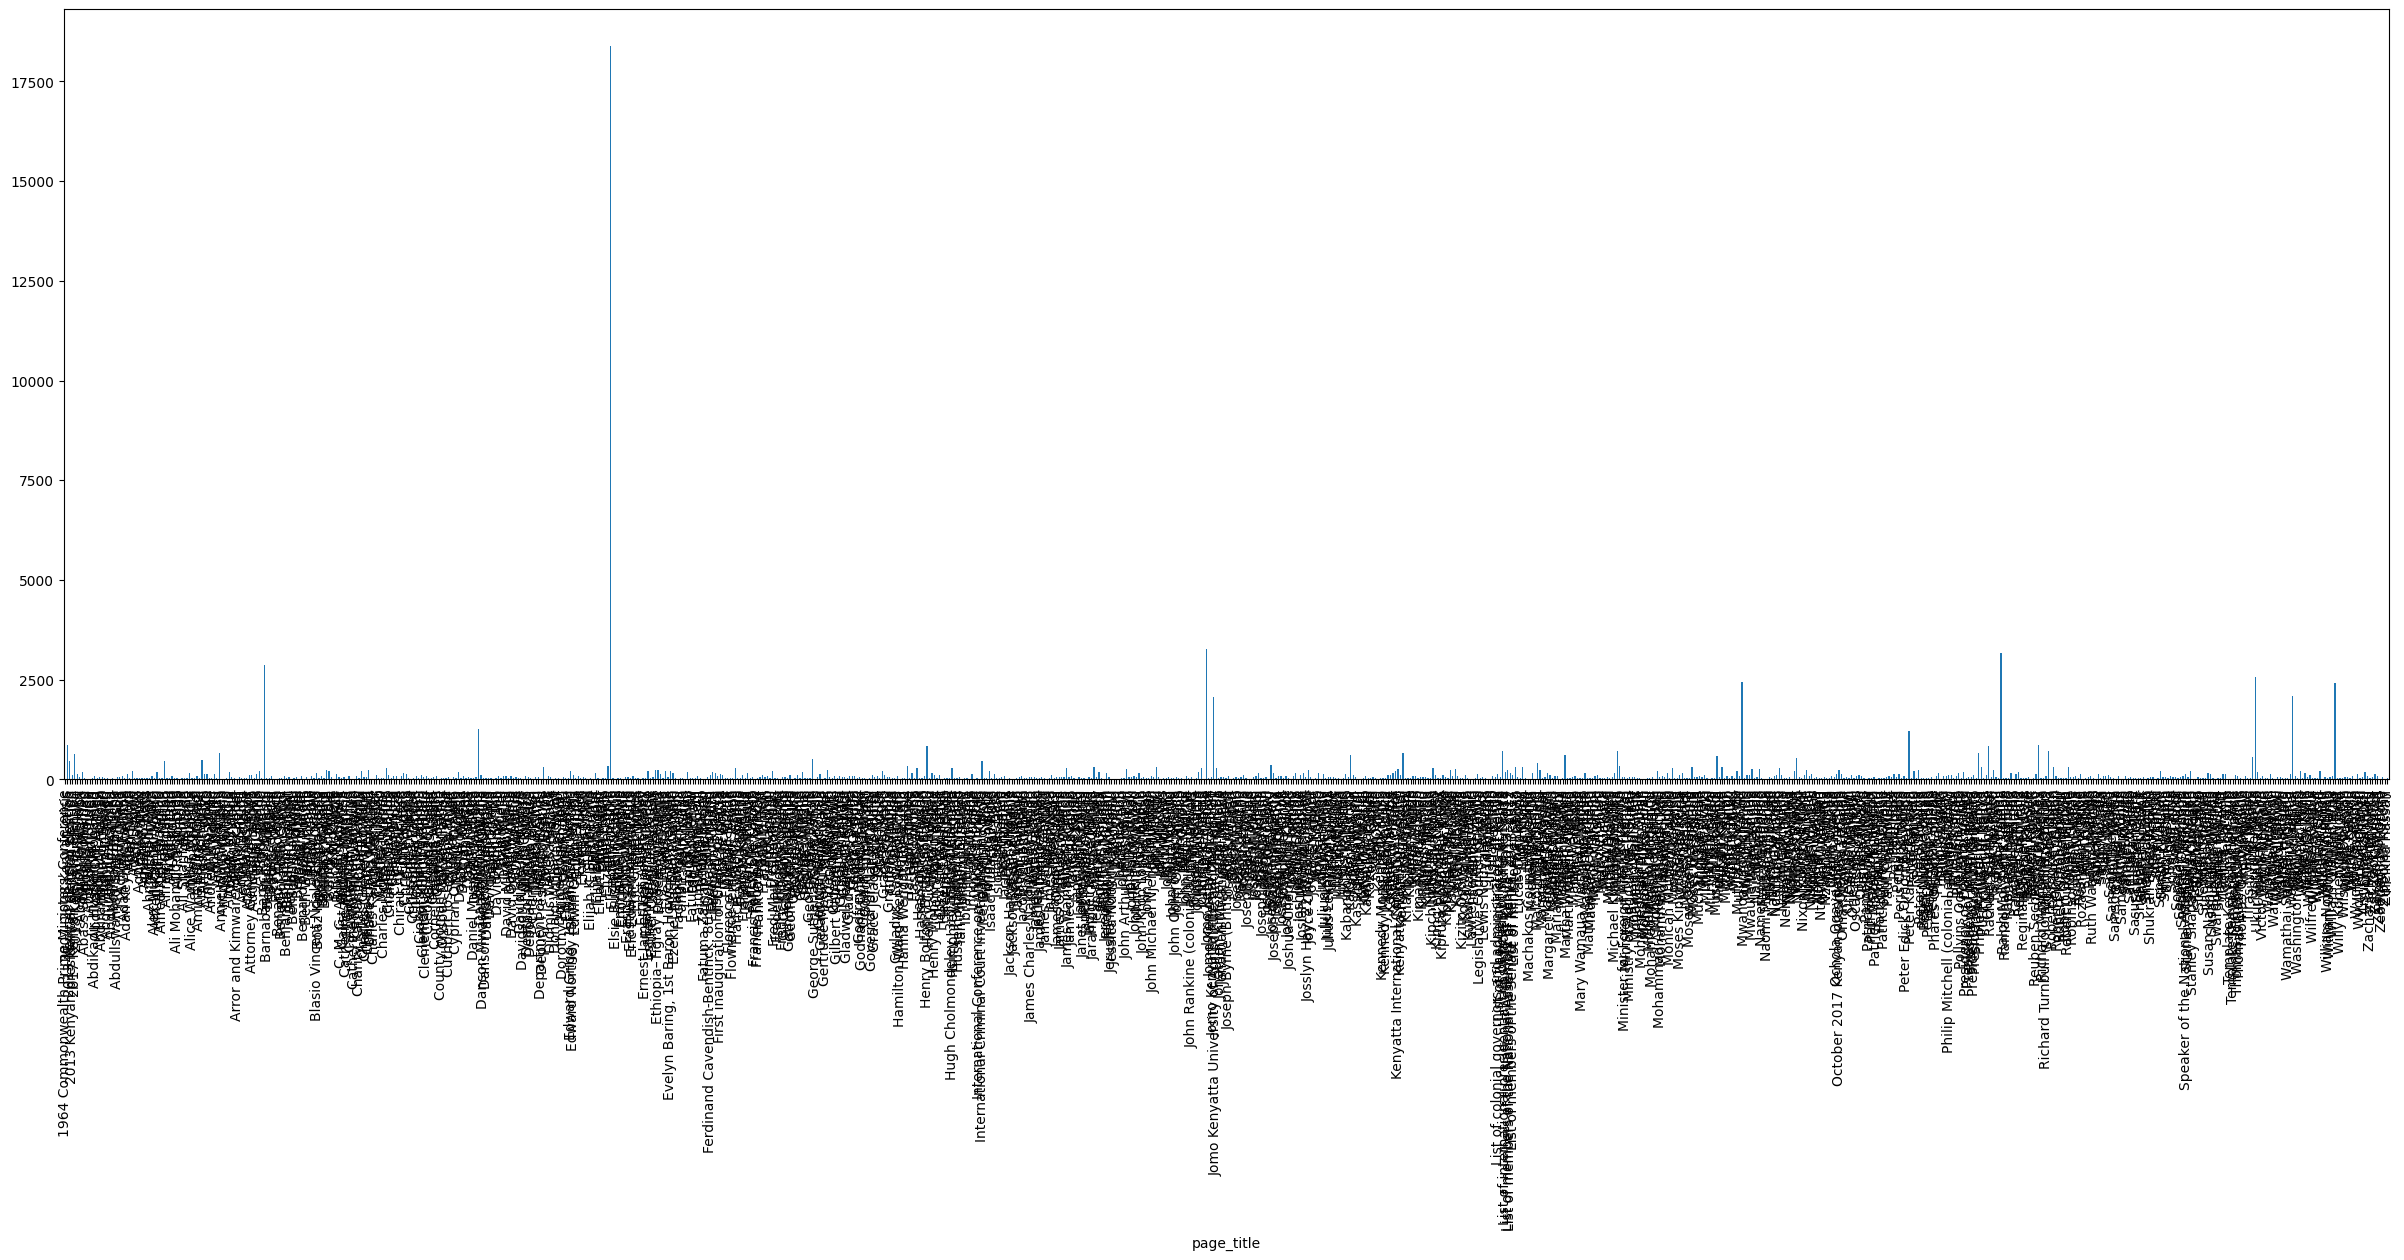

In [148]:
df_politicians.groupby(["page_title"]).count()['user'].plot(kind='bar',figsize=(30,10))

Seems like there's one article with a huge number of edits compared to all others. Plus, there are some more that stand out. Let's try to find those:

In [191]:
df_politicians.groupby(['page_title']).count().sort_values(by=['revid'], ascending=False).head(9)

,revid,parentid,minor,user,userid,timestamp,size,sha1,roles,slots,...,tags,anon,userhidden,commenthidden,text,contentmodel,size_difference,temp,sha1hidden,suppressed
page_title,,,,,,,,,,,,,,,,,,,,,
Elizabeth II,18393,18393,18393,18393,18393,18393,18393,18390,18393,18393,...,18393,18393,18393,18393,18390,18393,18393,0,3,0
Jomo Kenyatta,3268,3268,3268,3268,3268,3268,3268,3266,3268,3268,...,3268,3268,3268,3268,3266,3268,3268,0,2,0
Raila Odinga,3157,3157,3157,3157,3157,3157,3157,3141,3157,3157,...,3157,3157,3157,3157,3141,3157,3157,0,16,0
Barack Obama Sr.,2876,2876,2876,2876,2867,2876,2876,2840,2876,2876,...,2876,2876,2876,2876,2840,2876,2876,0,36,0
Uhuru Kenyatta,2554,2554,2554,2554,2554,2554,2554,2544,2554,2554,...,2554,2554,2554,2554,2544,2554,2554,19,10,1
Mwai Kibaki,2436,2436,2436,2436,2436,2436,2436,2436,2436,2436,...,2436,2436,2436,2436,2436,2436,2436,5,0,0
William Ruto,2420,2420,2420,2420,2420,2420,2420,2414,2420,2420,...,2420,2420,2420,2420,2414,2420,2420,9,6,0
Wangarĩ Maathai,2088,2088,2088,2088,2088,2088,2088,2080,2088,2088,...,2088,2088,2088,2088,2080,2088,2088,5,8,0
Jomo Kenyatta International Airport,2072,2072,2072,2072,2072,2072,2072,2072,2072,2072,...,2072,2072,2072,2072,2072,2072,2072,4,0,0


If we look closely, there seems to be something noteworthy with those search results: Why did the pages for *"Elizabeth II"* and *"Jomo Kenyatta International Airport"* make our list of politicians?! Let's hold that thought for a bit longer, when we'll explore an alternative way to narrow down our pages of interest.

### Creating a dataframe for editor details

For now, let's do a similar approach for saving the details of the editors that have touched those pages that we have identified.

For a start, let's just save the basic statistics for them, namely their total edit counts, gender (if entered), and whether they are registered users and/or bots.

Bots in Wikimedia are marked by the user group they belong to, so we can use the `.groups()` method and check if the account is part of it.

*Note: Getting all those user details will take a long while, given that it's > 20.000, so for demonstration purposes, the code below only does it for the first 100 users. The graphs below are actually looking at the full set of editors though*

In [ ]:
df_users = pd.DataFrame()

count = 0

for user in df_politicians['user'].unique():
    user = pywikibot.User(site, user) # get user object to manipulate
    groups = user.groups()
    if "bot" in groups: # to make it easier to see if user is a bot
        bot = True
    else:
        bot = False
    if len(user.first_edit) > 2: # doesn't necessarily exist for some reason
        first_edit = user.first_edit[2]
    else:
        first_edit = None
    if len(user.last_edit) > 2: # doesn't necessarily exist for some reason
        last_edit = user.last_edit[2]
    else:
        last_edit = None    
    df = pd.DataFrame([{
        'username' : user.username,
        'is_blocked': user.is_blocked(),
        'gender': user.gender(),
        'is_bot': bot,
        'first_edit': first_edit,
        'last_edit': last_edit,
        'editCount': user.editCount()
    }]
    )
    if not df_users.empty:
        df_users = pd.concat([df_users, df])
    else:
        df_users = df
    count += 1 
    if count > 100:
        #pass
        # otherwise, this runs for a very long time to actually get all the user data!
        break

df_users.head(100)

In [192]:
# Use this to save the full list of users if you've used it, by uncommenting the line below

# df_users.to_csv('users_who_edited_kenyian_politicians.csv')

#### Plotting the edit per user

Now, we can look at the editing behaviour of all of those users – across all articles they edited – by starting to make some plots. 

Let's start with a basic histogram over the edit counts. The x-axis will show us the number of edits in bins, the y-axis how many users made that many edits:

<Axes: ylabel='Frequency'>

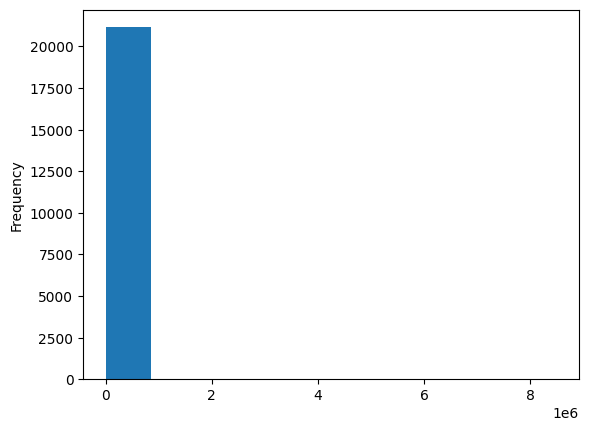

In [21]:
df_users['editCount'].plot(kind='hist')

That looks not super informative. The reason is that by default the plot command only creates 10 bins for the histogram. Plus, as for most online communities, we see a very strong participation inequality, also known as [the 1% rule](https://en.wikipedia.org/wiki/1%25_rule). 

Let's use a logarithmic scale for the y-axis, create 200 instead of 10 bins and disable the scientific notation on the x-axis:

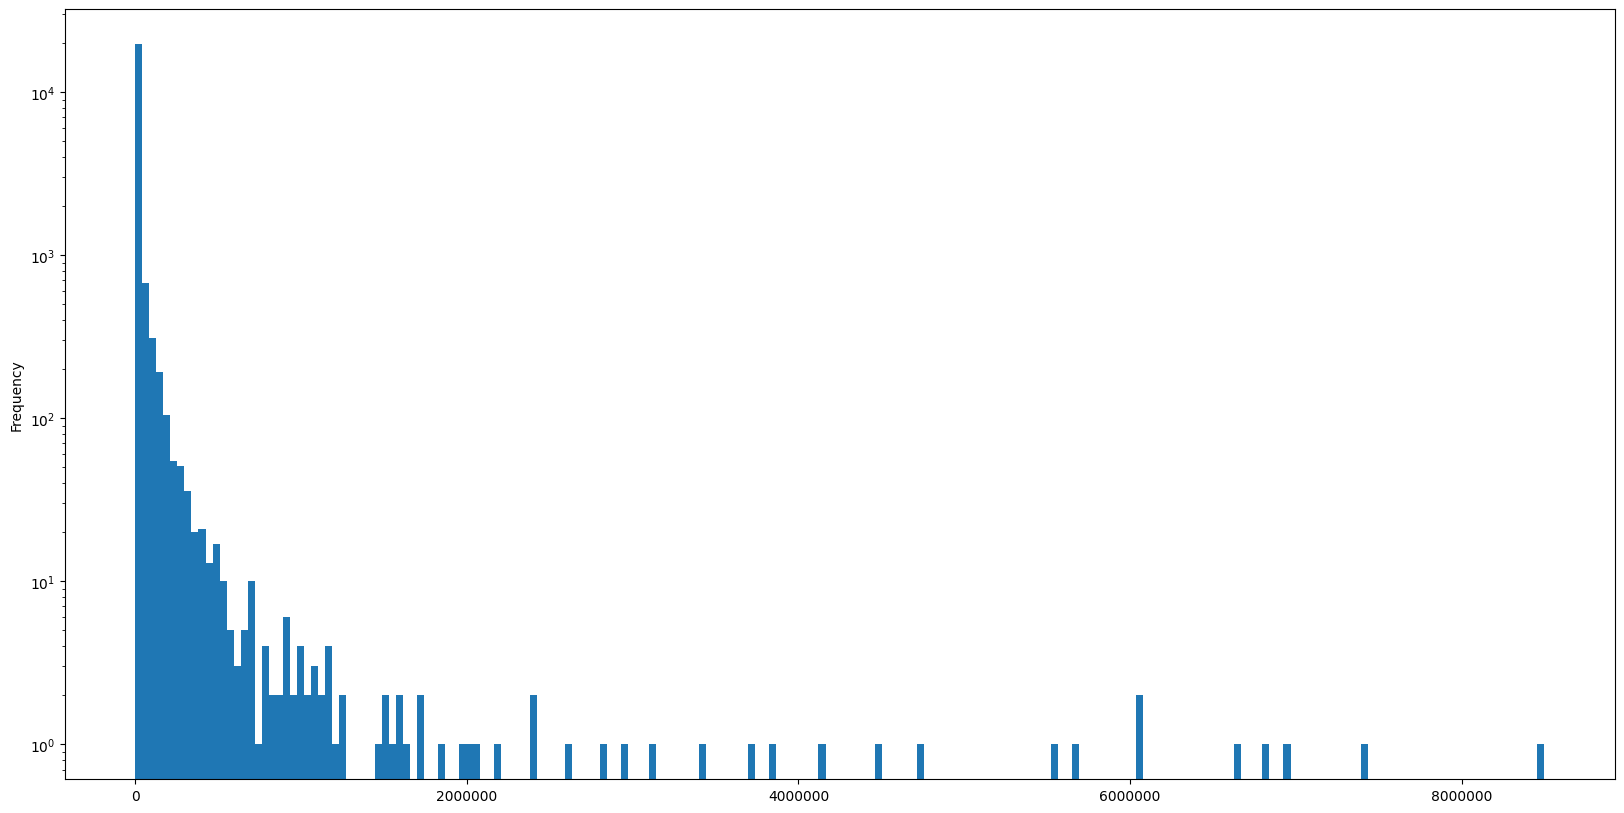

In [40]:
ax = df_users['editCount'].plot(kind='hist', bins=200,logy=True, figsize=(20,10))
ax.ticklabel_format(style='plain',axis='x')

That already looks more insightful. Es expected, the largest part of our users made compartively few edits, while there's a few outliers that did a lot of edits.

We can now also split this graph into those users who are bots and those who arent:

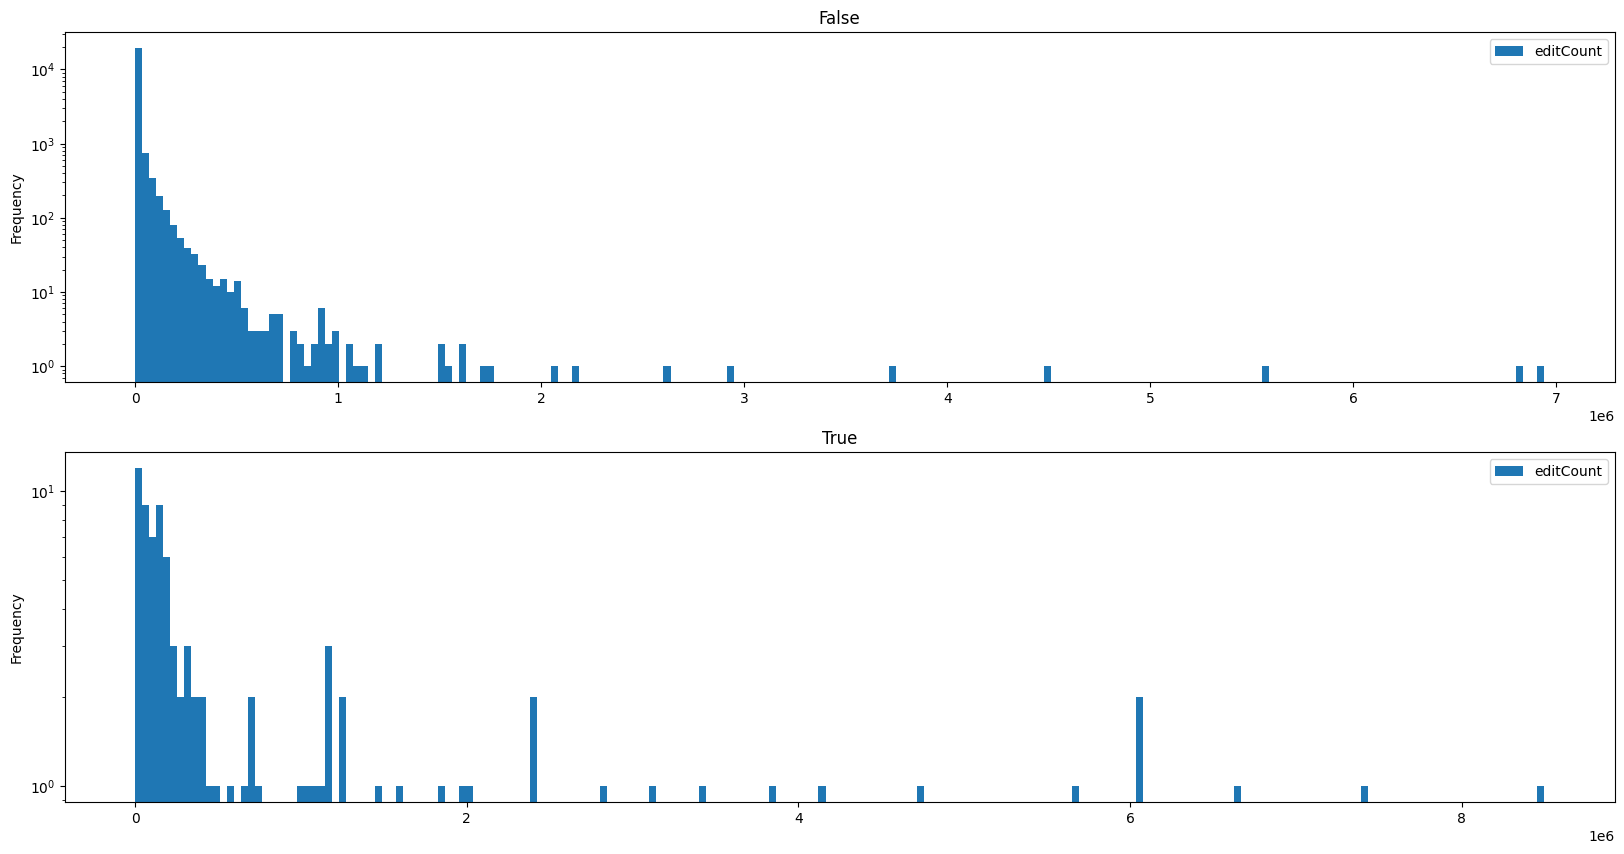

In [197]:
df_users = df_users.set_index('username')
df_users.plot.hist(column='editCount',by='is_bot',bins=200,logy=True, figsize=(20,10))
df_users = df_users.reset_index()

We can see that amongst the bots, there are more accounts with very large numbers of edits, as one would expect for automated editing. But: Even among the human editors, there are a few outliers that made between 3,000,000 and nearly 7,000,000 edits!

We can now also try to split the graph by the user-provided gender information, after exploring the distribution of responses by users:

<Axes: xlabel='User-provided gender', ylabel='Count'>

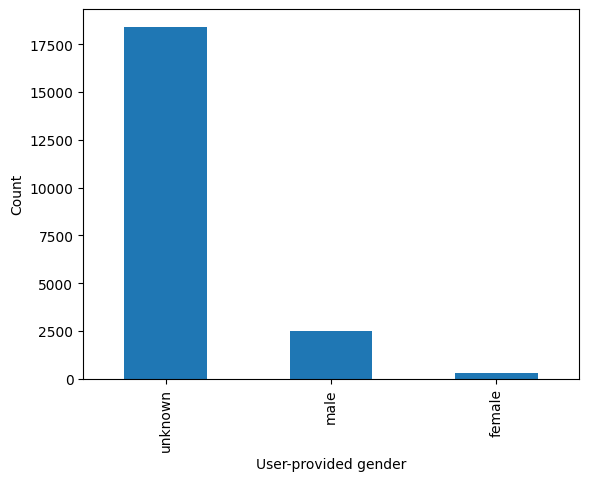

In [225]:
df_users['gender'].value_counts().plot(kind='bar', xlabel='User-provided gender', ylabel='Count')

We see that the vast majority of users did not specify their gender through the MediaWiki settings. If we focus on the gender breakdown only for the ~3000 users who did specify it, we see that ~15% of users gave their gender as female.

<Axes: xlabel='User-provided gender', ylabel='Count'>

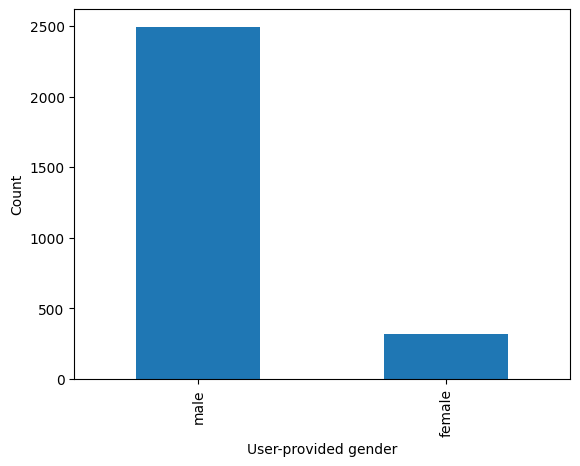

In [222]:
df_users[df_users['gender'] != 'unknown']['gender'].value_counts().plot(
    kind='bar', xlabel='User-provided gender', ylabel='Count')

We can now break down the editing history:

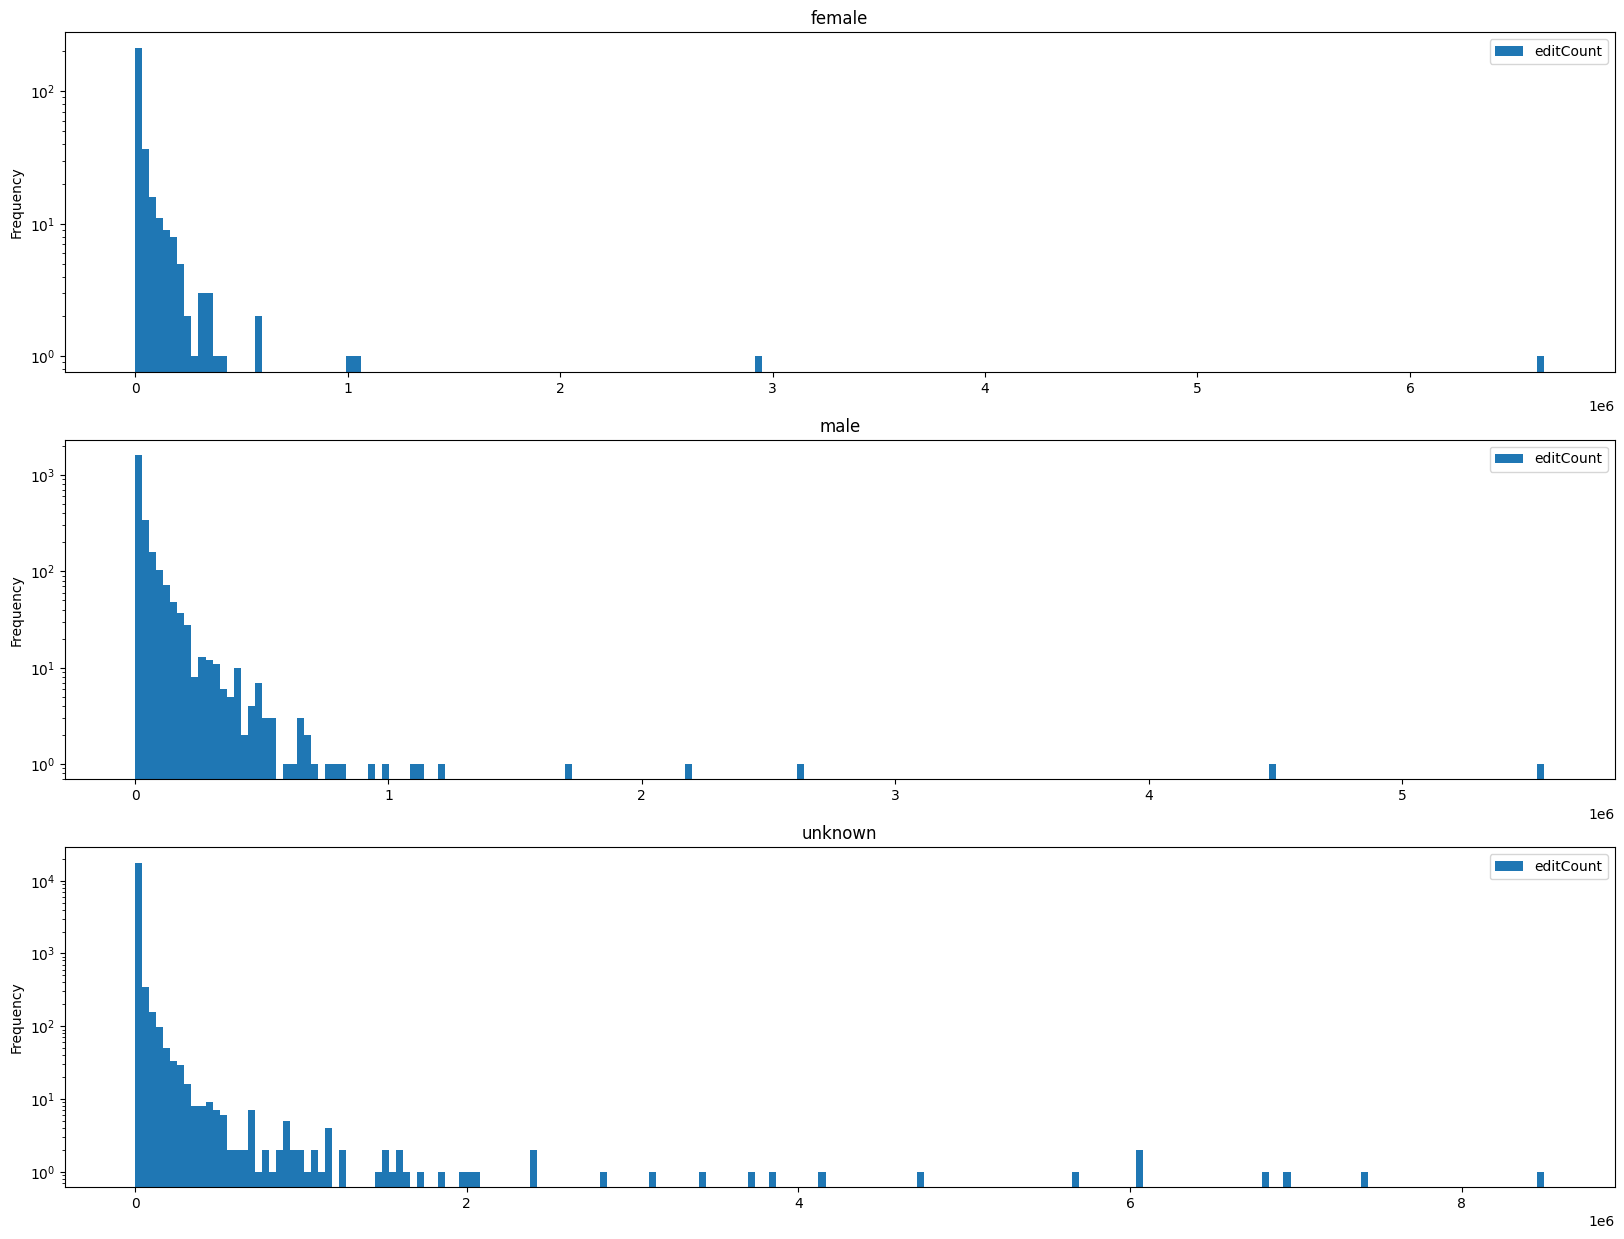

In [224]:

df_users = df_users.set_index('username')
df_users.plot.hist(column='editCount',by='gender',bins=200,logy=True, figsize=(20,15))
df_users = df_users.reset_index()

## Conclusions & Summary

We've seen how the *MediaWiki Actions API* can be interfaced with through the `pywikibot` library to get details about Wikipedia categories, individual pages along with their editing histories and contributors, and about contributors generally.

We have also explored how we can connect all of these to create a simple data set that we can re-use for more in-depth analyses later on.

But, we have also seen that our way of collecting this data maybe is not ideal yet, as our pages that we sourced from the `Kenyan politicans` page included unexpected pages, such as the *Jomo Kenyatta International Airport*. In the next bit, we'll see how we can query Wikidata to find more specific pages, by filtering for the properties of the page subjects (e.g. if they are people or not). 